In [2]:
# !pip install aiomoex
# !pip install tinkoff-investments
# !pip install yfinance

In [3]:
# !pip install git+https://github.com/tinkoff/invest-python.git --no-deps
# !pip install tensorflow==2.15.0 scikit-learn matplotlib pandas
# !pip install cachetools deprecation python-dateutil
# Устанавливаем конкретную версию cachetools, которую просит Тинькофф
# !pip install "cachetools>=5.2.0,<6.0.0"
# !pip install dotenv
# !pip install fastparquet

# !pip uninstall -y pandas pyarrow
# !pip install "pandas>=2.0.0" "pyarrow>=11.0.0"
# !pip install seaborn

Открытые вопросы:
* Стоит ли описывать варианты получения данных и причину выбора?

Что нужно сделать ближайшее:
* Выгрузить IMOEX индекс на периоде для сравнения (в идеале потом можно еще с открытием вкладов сравнить, но сложно кодом считать)
* Реализовать функции расчета индикаторов, которые необходимы будут для обучения


In [4]:
from tinkoff.invest import Client, AsyncClient, CandleInterval, SecurityTradingStatus, InstrumentStatus
from tinkoff.invest.services import InstrumentsService
from tinkoff.invest.utils import quotation_to_decimal, now
from tinkoff.invest.caching.instruments_cache.instruments_cache import InstrumentsCache

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

import pyarrow
import pandas as pd
from pandas.tseries.offsets import DateOffset
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
# import asyncio
import math

import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Optional

from dotenv import load_dotenv

import warnings
warnings.filterwarnings("ignore")

In [5]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [6]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [7]:
load_dotenv()

# TOKEN = "REDACTED"
TOKEN = os.getenv("TOKEN")

In [8]:
TRAIN_MONTHS = 24  # Длительность обучения (2 года в статье)
TEST_MONTHS = 1    # Как часто переобучаем модель и тестируем (например, раз в месяц)
WINDOW_SIZE = 24   # Размер входного окна (24 свечи = 2 часа для 5-мин)
ALPHA = 0.55       # Порог волатильности для таргета

In [9]:
tickers_to_test = ["SBER", "GLDRUB_TOM", "CNYRUB_TOM", "BRH6", "MOEX"]

Словарь настроек интервалов: (Константа API, Максимальный шаг скачивания)

In [10]:
INTERVALS = {
    "5min":  (CandleInterval.CANDLE_INTERVAL_5_MIN, timedelta(days=7)),
    "15min": (CandleInterval.CANDLE_INTERVAL_15_MIN, timedelta(days=21)),
    "1hour": (CandleInterval.CANDLE_INTERVAL_HOUR, timedelta(days=31)),
    "4hour": (CandleInterval.CANDLE_INTERVAL_4_HOUR, timedelta(days=31 * 2)),
    "1day":  (CandleInterval.CANDLE_INTERVAL_DAY, timedelta(days=365))
}

In [11]:
market_context = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Inflation': [0.1291, 0.0538, 0.0252, 0.0427, 0.0305, 0.0491, 0.0839, 0.1192, 0.0742, 0.0951, 0.0599],
    'BankRate':  [0.15325, 0.0999, 0.084, 0.07245, 0.07529, 0.05927, 0.04486, 0.07738, 0.0813, 0.14793, 0.21723]
}
df_market = pd.DataFrame(market_context).set_index('Year')

Подробная информация по тикеру.

**Не работает с индексами вроде индекса МосБиржи**

In [14]:
def get_info(ticker, TOKEN = TOKEN):
    with Client(TOKEN) as client:
        instruments: InstrumentsService = client.instruments
        tickers = []
        for method in ["shares", "bonds", "etfs", "currencies", "futures"]:
            for item in getattr(instruments, method)().instruments:
                tickers.append(
                    {
                        "name": item.name,
                        "ticker": item.ticker,
                        "class_code": item.class_code,
                        "figi": item.figi,
                        "uid": item.uid,
                        "type": method,
                        "min_price_increment": quotation_to_decimal(
                            item.min_price_increment
                        ),
                        "scale": 9 - len(str(item.min_price_increment.nano)) + 1,
                        "lot": item.lot,
                        "trading_status": str(
                            SecurityTradingStatus(item.trading_status).name
                        ),
                        "api_trade_available_flag": item.api_trade_available_flag,
                        "currency": item.currency,
                        "exchange": item.exchange,
                        "buy_available_flag": item.buy_available_flag,
                        "sell_available_flag": item.sell_available_flag,
                        "short_enabled_flag": item.short_enabled_flag,
                        "klong": quotation_to_decimal(item.klong),
                        "kshort": quotation_to_decimal(item.kshort),
                    }
                )

        tickers_df = pd.DataFrame(tickers)

        ticker_df = tickers_df[tickers_df["ticker"] == ticker]
        if ticker_df.empty:
            print("There is no such ticker: %s", ticker)
            # return

        figi = ticker_df["figi"].iloc[0]
        print(f"\nTicker {ticker} have figi={figi}\n")
        print(f"Additional info for this {ticker} ticker:")
        print(ticker_df.iloc[0])

        return figi

# ticker = "SBER"
# get_info(ticker)

Получить только FIGI.

In [15]:
def get_figi(ticker: str) -> str:
    ticker = ticker.upper()
    with Client(TOKEN) as client:
        response = client.instruments.find_instrument(query=ticker)
        
        # 1. Сначала ищем идеальный вариант: совпадение тикера + доступность для торгов
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                # Маленький лайфхак: для акций РФ основной режим торгов - TQBR (акции) или SPBFUT (фьючерсы)
                if instrument.class_code in ['TQBR', 'TQCB', 'SPBFUT', 'CETS', 'TQTF']:
                    print(f"Подтверждено: {ticker} ({instrument.name}), FIGI: {instrument.figi}")
                    return instrument.figi
        
        # 2. Если идеальный не нашли, берем любой доступный с точным тикером
        for instrument in response.instruments:
            if instrument.ticker == ticker and instrument.api_trade_available_flag:
                return instrument.figi
                
        raise ValueError(f"Не удалось найти активный торговый инструмент для тикера {ticker}")

In [16]:
for t in tickers_to_test:
    try:
        figi = get_figi(t)
        print(f"Успех! {t} -> {figi}")
    except Exception as e:
        print(f"Ошибка для {t}: {e}")

Подтверждено: SBER (Сбер Банк), FIGI: BBG004730N88
Успех! SBER -> BBG004730N88
Подтверждено: GLDRUB_TOM (Золото), FIGI: BBG000VJ5YR4
Успех! GLDRUB_TOM -> BBG000VJ5YR4
Подтверждено: CNYRUB_TOM (Китайский юань), FIGI: BBG0013HRTL0
Успех! CNYRUB_TOM -> BBG0013HRTL0
Подтверждено: BRH6 (BR-3.26 Нефть Brent), FIGI: FUTBR0326000
Успех! BRH6 -> FUTBR0326000
Ошибка для MOEX: 9 is not a valid InstrumentType


In [17]:
def get_5min(ticker: str) -> pd.DataFrame:
    ticker = ticker.upper()
    file_path = DATA_DIR / f"{ticker}_5min.parquet"

    # Если файл есть — читаем и сразу делаем DateTime колонкой
    if file_path.exists():
        print(f"Загружаю из кэша: {ticker}")
        df = pd.read_parquet(file_path)
        if df.index.name == "DateTime":
            df = df.reset_index()
        return df.sort_values("DateTime", ascending=False)

    # Если файла нет — скачиваем
    print(f"Скачиваю {ticker} с 01.01.2025...")
    figi = get_figi(ticker)
    new_rows = []
    current = datetime(2025, 1, 1)
    now = datetime.now()

    with Client(TOKEN) as client:
        while current < now:
            end = min(current + timedelta(days=7), now - timedelta(minutes=10))

            if end <= current:
                break

            for _ in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current,
                        to=end,
                        interval=CandleInterval.CANDLE_INTERVAL_5_MIN
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    print(f"  +{len(candles)} свечей → {end.strftime('%Y-%m-%d %H:%M')}")
                    break
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        print("Лимит! Жду 45 сек...")
                        time.sleep(45)
                    else:
                        time.sleep(5)
            else:
                print(f"Не удалось скачать кусок {current.date()} → {end.date()}")
            
            current = end
            time.sleep(1.2)

    if not new_rows:
        raise RuntimeError(f"Не удалось скачать данные для {ticker}")

    df = pd.DataFrame(new_rows)
    df = df.sort_values("DateTime", ascending=False)
    
    df.to_parquet(file_path, compression="zstd", index=False)
    print(f"Сохранено: {file_path} → {len(df):,} строк")

    return df

In [18]:
def get_candles_data(ticker: str, 
                     interval_name: str = "5min",
                     start_date: datetime = datetime(2025, 1, 1), 
                     end_date: Optional[datetime] = None) -> pd.DataFrame:
    """
    Загружает исторические свечи, используя локальное кэширование в Parquet.
    Решает проблему смешивания tz-aware и tz-naive дат.
    """
    ticker = ticker.upper()
    if interval_name not in INTERVALS:
        raise ValueError(f"Неверный интервал. Доступные: {list(INTERVALS.keys())}")
    
    t_interval, chunk_step = INTERVALS[interval_name]
    file_path = DATA_DIR / f"{ticker}_{interval_name}.parquet"
    
    # 1. Нормализация дат (приводим всё к naive - без часовых поясов для сравнения)
    if start_date.tzinfo is not None:
        start_date = start_date.replace(tzinfo=None)
    
    if end_date is None:
        end_date = datetime.now()
    elif end_date.tzinfo is not None:
        end_date = end_date.replace(tzinfo=None)

    df = pd.DataFrame()

    # 2. Проверка локального кэша
    if file_path.exists():
        df = pd.read_parquet(file_path)
        # Очищаем кэшированные данные от TZ для корректного сравнения
        df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
        
        if not df.empty:
            cache_min = df['DateTime'].min()
            cache_max = df['DateTime'].max()
            
            # Если кэш покрывает запрошенный период (с запасом в 1 час)
            if cache_min <= start_date and cache_max >= (end_date - timedelta(minutes=60)):
                print(f"[{ticker}] Данные полностью взяты из кэша.")
                mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
                return df.loc[mask].sort_values("DateTime", ascending=False)
            
            print(f"[{ticker}] Кэш неполный. Докачиваю недостающее...")

    # 3. Скачивание данных через API
    figi = get_figi(ticker) # Убедитесь, что функция get_figi определена
    new_rows = []
    
    # Для API Тинькофф нужны даты с часовым поясом (UTC)
    current_download = start_date.replace(tzinfo=timezone.utc)
    target_end = end_date.replace(tzinfo=timezone.utc)
    
    with Client(TOKEN) as client:
        while current_download < target_end:
            chunk_end = min(current_download + chunk_step, target_end)

            for attempt in range(3):
                try:
                    candles = client.market_data.get_candles(
                        figi=figi,
                        from_=current_download,
                        to=chunk_end,
                        interval=t_interval
                    ).candles

                    for c in candles:
                        new_rows.append({
                            "DateTime": c.time,
                            "Open":  c.open.units  + c.open.nano  / 1e9,
                            "High":  c.high.units  + c.high.nano  / 1e9,
                            "Low":   c.low.units   + c.low.nano   / 1e9,
                            "Close": c.close.units + c.close.nano / 1e9,
                            "Volume": c.volume
                        })
                    break 
                except Exception as e:
                    if "RESOURCE_EXHAUSTED" in str(e):
                        print("Лимит запросов! Жду 45 сек...")
                        time.sleep(45)
                    else:
                        print(f"Ошибка: {e}. Пробую снова...")
                        time.sleep(5)
            
            current_download = chunk_end
            time.sleep(0.5) # Небольшая пауза между чанками

    # 4. Объединение, очистка и сохранение
    if new_rows:
        new_df = pd.DataFrame(new_rows)
        # Сразу очищаем новые данные от TZ
        new_df['DateTime'] = pd.to_datetime(new_df['DateTime']).dt.tz_localize(None)
        
        df = pd.concat([df, new_df]).drop_duplicates(subset=['DateTime'])
    
    if df.empty:
        raise RuntimeError(f"Не удалось получить данные для {ticker}")

    # Сортируем и сохраняем полный кэш
    df = df.sort_values("DateTime", ascending=False)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(file_path, compression="zstd", index=False)
    
    # Возвращаем только запрошенный диапазон
    mask = (df['DateTime'] >= start_date) & (df['DateTime'] <= end_date)
    return df.loc[mask]

In [19]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [20]:
def prepare_daily_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Превращает любые данные (минуты, часы) в чистые дневные бары для стратегий.
    """
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    
    # Агрегируем: Open - первый в дне, Close - последний, Volume - сумма
    df_daily = df.resample('D').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })
    
    # Заполняем выходные и праздники (биржи закрыты, цена не менялась)
    df_daily[['Open', 'High', 'Low', 'Close']] = df_daily[['Open', 'High', 'Low', 'Close']].ffill()
    df_daily['Volume'] = df_daily['Volume'].fillna(0)
    
    return df_daily.sort_index()

In [21]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

In [22]:
def add_technical_indicators(df: pd.DataFrame, 
                             sma_periods: list = [20, 50, 200],
                             ema_periods: list = [12, 26],
                             rsi_period: int = 14,
                             macd_fast: int = 12,
                             macd_slow: int = 26,
                             macd_signal: int = 9,
                             bb_period: int = 20,
                             cci_period: int = 20,
                             adx_period: int = 14,
                             roc_period: int = 12,
                             cmf_period: int = 20) -> pd.DataFrame:
    """
    Добавляет полный набор технических индикаторов (Lagging, Leading, Neutral).
    """
    df = df.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    
    # --- LAGGING INDICATORS ---
    
    # SMA & EMA
    for period in sma_periods:
        df[f'SMA_{period}'] = close.rolling(window=period).mean()
    for period in ema_periods:
        df[f'EMA_{period}'] = close.ewm(span=period, adjust=False).mean()
    
    # MACD
    ema_f = close.ewm(span=macd_fast, adjust=False).mean()
    ema_s = close.ewm(span=macd_slow, adjust=False).mean()
    df['MACD'] = ema_f - ema_s
    df['MACD_Signal'] = df['MACD'].ewm(span=macd_signal, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
    # Bollinger Bands
    sma_bb = close.rolling(window=bb_period).mean()
    std_bb = close.rolling(window=bb_period).std()
    df['BB_Upper'] = sma_bb + (2 * std_bb)
    df['BB_Lower'] = sma_bb - (2 * std_bb)
    
    # --- LEADING INDICATORS ---
    
    # RSI
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=rsi_period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=rsi_period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # CCI (Commodity Channel Index)
    tp = (high + low + close) / 3
    sma_tp = tp.rolling(window=cci_period).mean()
    mad_tp = tp.rolling(window=cci_period).apply(lambda x: np.abs(x - x.mean()).mean())
    df['CCI'] = (tp - sma_tp) / (0.015 * mad_tp)
    
    # VWAP (Volume Weighted Average Price)
    # Считается накопительно, если данные внутри дня, или скользящим окном
    df['VWAP'] = (volume * (high + low + close) / 3).cumsum() / volume.cumsum()
    
    # OBV (On-Balance Volume)
    df['OBV'] = (np.sign(close.diff()) * volume).fillna(0).cumsum()
    
    # ADX (Average Directional Index)
    plus_dm = high.diff().where((high.diff() > low.diff().abs()) & (high.diff() > 0), 0)
    minus_dm = low.diff().abs().where((low.diff().abs() > high.diff()) & (low.diff().abs() > 0), 0)
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    atr = tr.rolling(window=adx_period).mean()
    plus_di = 100 * (plus_dm.rolling(window=adx_period).mean() / atr)
    minus_di = 100 * (minus_dm.rolling(window=adx_period).mean() / atr)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df['ADX'] = dx.rolling(window=adx_period).mean()
    
    # ADL (Accumulation Distribution Line)
    mfm = ((close - low) - (high - close)) / (high - low)
    mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0) # Защита от zero division если high==low
    df['ADL'] = (mfm * volume).cumsum()
    
    # CMF (Chaikin Money Flow)
    mfv = mfm * volume
    df['CMF'] = mfv.rolling(window=cmf_period).sum() / volume.rolling(window=cmf_period).sum()
    
    # --- NEUTRAL / MOMENTUM INDICATORS ---
    
    # ROC (Rate of Change)
    df['ROC'] = ((close - close.shift(roc_period)) / close.shift(roc_period)) * 100
    
    return df

Стратегия DCA (Dollar Cost Averaging)
Вы покупаете 10-го и 25-го числа. Если день выходной, мы берем ближайший предыдущий рабочий день

In [23]:
def benchmark_dca(df: pd.DataFrame, investment_per_step: float = 1000, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    # 1. Подготовка индекса
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
    
    df.index = df.index.normalize()
    df = df.sort_index()

    # 2. Фильтрация и агрегация до дней (на случай интрадея)
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    total_shares = 0
    total_invested = 0
    current_cash = 0 
    daily_history = []

    # 3. Основной цикл стратегии
    for date, row in df.iterrows():
        if date.day in [10, 25]:
            buy_price = row['Open']
            if buy_price > 0:
                available_money = investment_per_step + current_cash
                total_invested += investment_per_step
                
                max_shares = available_money / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares_to_buy = num_lots * lot_size
                
                purchase_cost = shares_to_buy * buy_price
                total_fee = purchase_cost * fee
                
                total_shares += shares_to_buy
                current_cash = available_money - (purchase_cost + total_fee)
        
        portfolio_value = (total_shares * row['Close']) + current_cash
        
        daily_history.append({
            'DateTime': date,
            'Balance': portfolio_value,
            'Invested': total_invested
        })

    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    if temp_df.empty: return 0.0, 0.0, pd.DataFrame()

    # 4. Агрегация в годовую таблицу
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        if len(annual_history) == 0:
            # Первый год: база для профита — это первые внесенные деньги
            first_invested = year_data[year_data['Invested'] > 0]['Invested'].iloc[0] if any(year_data['Invested'] > 0) else 0
            profit = last_balance - invested_at_end
            prev_balance = first_invested
        else:
            prev_balance = annual_history[-1]['Balance']
            # Пополнения за текущий год
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            # Прибыль = Конец года - (Начало года + Довнесения)
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / (prev_balance + (invested_at_end - (annual_history[-1]['Invested'] if len(annual_history) > 0 else 0)) / 2)
        # Упрощенный Rate для наглядности (как в банковской таблице)
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Итоговые метрики
    final_balance = history_df['Balance'].iloc[-1]
    final_profit_pct = ((final_balance - total_invested) / total_invested * 100) if total_invested > 0 else 0
    
    return final_profit_pct, final_balance, history_df

Стратегия "Sell in May and Go Away"
Классическая поговорка гласит: «Продавай в мае и уходи, возвращайся в День всех святых (ноябрь)». Логика: Мы владеем активом только с 1 ноября по 30 апреля. В остальное время мы «в кэше» (деньги просто лежат)

In [24]:
def benchmark_sell_in_may(df: pd.DataFrame, initial_capital: float = 100000, n: float = 0, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
            
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    # Гарантируем дневной формат, чтобы не множить комиссии на интрадее
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    in_market_months = [11, 12, 1, 2, 3, 4]
    current_cash = initial_capital
    total_invested = initial_capital 
    shares = 0
    in_position = False
    daily_history = []
    n_added_this_year = False

    for date, row in df.iterrows():
        month = date.month
        if month == 11: n_added_this_year = False
        
        # Логика входа (Ноябрь)
        if month in in_market_months and not in_position:
            buy_price = row['Open']
            if buy_price > 0:
                max_shares = current_cash / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares = num_lots * lot_size
                current_cash -= (shares * buy_price * (1 + fee))
                in_position = True
            
        # Логика выхода (Май)
        elif month not in in_market_months and in_position:
            sell_price = row['Open']
            if sell_price > 0:
                current_cash += (shares * sell_price * (1 - fee))
                shares = 0
                in_position = False
            
            if not n_added_this_year:
                current_cash += n
                total_invested += n
                n_added_this_year = True

        current_balance = current_cash + (shares * row['Close'] if in_position else 0)
        daily_history.append({
            'DateTime': date, 
            'Balance': current_balance, 
            'Invested': total_invested
        })

    # Создаем ежедневный DF для последующей агрегации
    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    
    # Агрегируем данные по годам
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        # Расчет прибыли и доходности за год
        if len(annual_history) == 0:
            prev_balance = initial_capital
            profit = last_balance - initial_capital
        else:
            prev_balance = annual_history[-1]['Balance']
            # Прибыль = Текущий баланс - (Предыдущий баланс + пополнение в этом году)
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Финальные метрики
    final_balance = history_df['Balance'].iloc[-1]
    net_profit = final_balance - total_invested
    total_return_pct = (net_profit / total_invested * 100) if total_invested > 0 else 0
    
    return total_return_pct, final_balance, history_df

In [25]:
df_SBER = get_candles_data("SBER", start_date=datetime(2015, 1, 1))
df_SBER = fill_time_gaps(df_SBER)
df_SBER = clean_market_data(df_SBER)

[SBER] Кэш неполный. Докачиваю недостающее...
Подтверждено: SBER (Сбер Банк), FIGI: BBG004730N88


In [26]:
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
print(ret_sim, val_sim, hist_sim)

32.073429999999995 132073.43    Year    Balance     Rate    Profit  Invested
0  2018   81173.02 -0.18827 -18826.98    100000
1  2019  106363.09  0.31033  25190.07    100000
2  2020  111281.44  0.04624   4918.35    100000
3  2021  100564.59 -0.09630 -10716.85    100000
4  2022   49629.17 -0.50649 -50935.42    100000
5  2023   85271.87  0.71818  35642.70    100000
6  2024  114684.44  0.34493  29412.57    100000
7  2025  129302.10  0.12746  14617.66    100000
8  2026  132073.43  0.02143   2771.33    100000


In [27]:
df_MOEX = get_candles_data("MOEX", start_date=datetime(2015, 1, 1))
df_MOEX = fill_time_gaps(df_MOEX)
df_MOEX = clean_market_data(df_MOEX)

ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_MOEX)
print(ret_sim, val_sim, hist_sim)

ValueError: 9 is not a valid InstrumentType

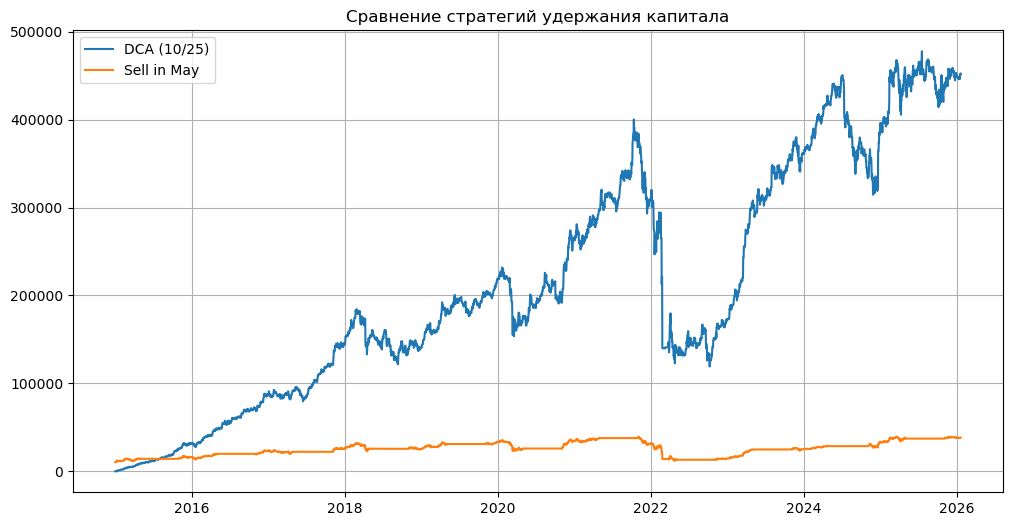

In [ ]:
# Получаем данные (пример)
ret_dca, val_dca, hist_dca = benchmark_dca(df_SBER)
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
# hist_dep — это history_df из предыдущей функции про вклады

plt.figure(figsize=(12, 6))

plt.plot(hist_dca.index, hist_dca['Balance'], label='DCA (10/25)')
plt.plot(hist_sim.index, hist_sim['Balance'], label='Sell in May')
# Если у вкладов индекс по годам, можно использовать .step() или аппроксимацию
# plt.plot(hist_dep['Year_Date'], hist_dep['Balance'], label='Bank Deposit')

plt.title('Сравнение стратегий удержания капитала')
plt.legend()
plt.grid(True)
plt.show()

Стратегия с банковским вкладом

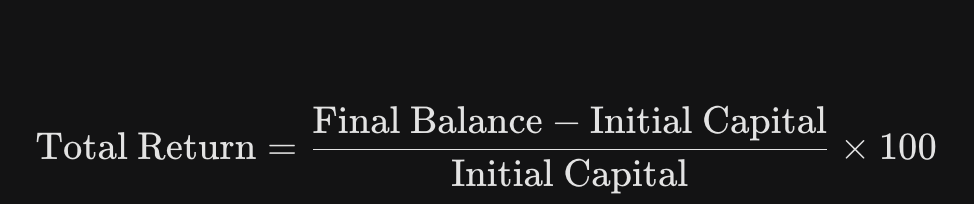

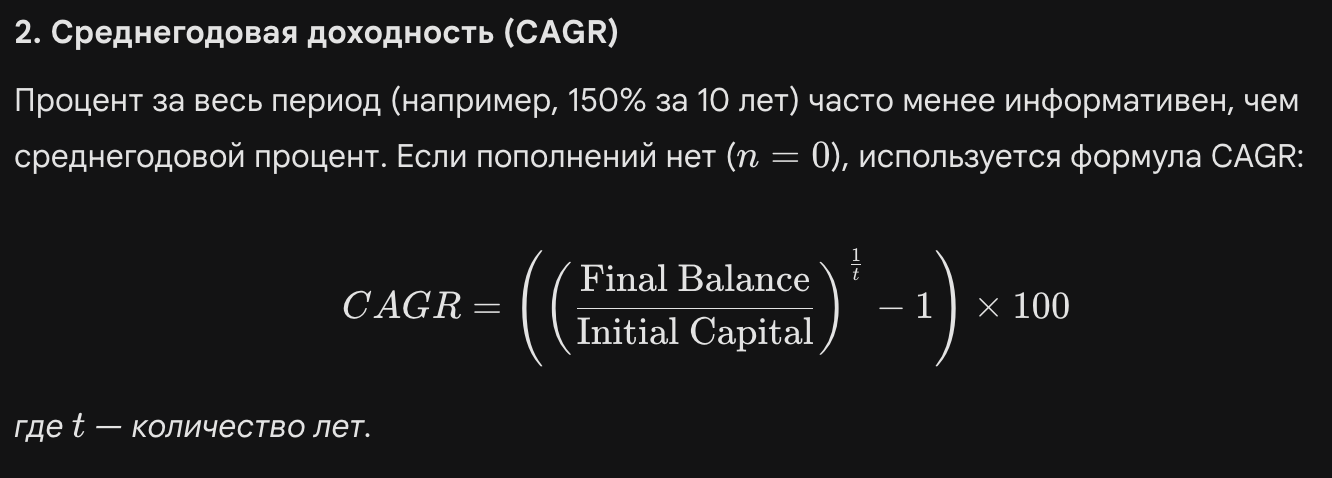

In [ ]:
def benchmark_deposit(df_rates: pd.DataFrame, initial_capital: float = 100000, n: float = 0, start_year: int = 2015, end_year: int = 2025) -> tuple[float, float, pd.DataFrame]:
    """
    initial_capital: Стартовая сумма
    n: Сумма ежегодной капитализации, если она есть
    df_rates: DataFrame с колонкой 'BankRate' и годами в индексе
    start_year: Год начала (int)
    end_year: Год окончания (int)
    
    Returns:
        tuple: (чистая_доходность_%, финальный_баланс, df_history)
    """
    current_balance = initial_capital
    total_invested = initial_capital  # Отслеживаем общую сумму внесенных средств
    history = []
    
    # Добавляем стартовую точку (начало первого года)
    history.append({
        'Year': start_year,
        'Balance': current_balance,
        'Rate': 0,
        'Profit': 0,
        'Invested': initial_capital
    })
    
    # Цикл по годам
    for year in range(start_year, end_year + 1):
        if year in df_rates.index:
            rate = df_rates.loc[year, 'BankRate']
            
            # В конце года получаем выплату
            profit = current_balance * rate
            current_balance += profit
            current_balance += n
            total_invested += n # Учитываем ежегодное пополнение в общей сумме вложений
            
            history.append({
                'Year': year + 1, # Состояние на 1 января следующего года
                'Balance': round(current_balance, 2),
                'Rate': rate,
                'Profit': round(profit, 2), 
                'Invested': round(current_balance, 2) - round(profit, 2)
            })
        else:
            print(f"Предупреждение: Ставка за {year} год не найдена.")
            
    # Превращаем историю в DataFrame для удобного построения графиков
    df_history = pd.DataFrame(history)
    
    # ИЗМЕНЕНИЕ: Считаем доходность только от заработанных процентов (Net ROI), 
    # а не просто разницу между началом и концом, чтобы не учитывать пополнения как прибыль.
    net_profit = current_balance - total_invested
    total_return_pct = (net_profit / total_invested) * 100
    
    return total_return_pct, current_balance, df_history

In [ ]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_deposit(df_market, start_cap, 1000, 2015, 2025)

print(f"Итоговая доходность вкладов: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность вкладов: 174.48%
Финальная сумма: 304677.78
    Year    Balance     Rate    Profit   Invested
0   2015  100000.00  0.00000      0.00  100000.00
1   2016  116325.00  0.15325  15325.00  101000.00
2   2017  128945.87  0.09990  11620.87  117325.00
3   2018  140777.32  0.08400  10831.45  129945.87
4   2019  151976.64  0.07245  10199.32  141777.32
5   2020  164418.96  0.07529  11442.32  152976.64
6   2021  175164.07  0.05927   9745.11  165418.96
7   2022  184021.93  0.04486   7857.86  176164.07
8   2023  199261.55  0.07738  14239.62  185021.93
9   2024  216461.51  0.08130  16199.96  200261.55
10  2025  249482.66  0.14793  32021.15  217461.51
11  2026  304677.78  0.21723  54195.12  250482.66


In [ ]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_sell_in_may(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность sell in may: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность sell in may: 24.65%
Финальная сумма: 124654.98
   Year    Balance     Rate    Profit  Invested
0  2018   81711.16 -0.18289 -18288.84    100000
1  2019  108682.54  0.33008  26971.38    100000
2  2020  111832.63  0.02898   3150.09    100000
3  2021  100726.22 -0.09931 -11106.41    100000
4  2022   47452.98 -0.52889 -53273.24    100000
5  2023   81706.94  0.72185  34253.96    100000
6  2024  110592.56  0.35353  28885.62    100000
7  2025  124654.98  0.12716  14062.42    100000


In [ ]:
start_cap = 1000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_dca(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность DCA {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность DCA 33.89%
Финальная сумма: 251709.18
   Year    Balance     Rate    Profit  Invested
0  2018   18096.32 -1.90368  -1903.68     20000
1  2019   51691.35  0.53022   9595.03     44000
2  2020   84528.56  0.17096   8837.21     68000
3  2021  114376.23  0.06918   5847.67     92000
4  2022   80580.46 -0.50531 -57795.77    116000
5  2023  182362.38  0.96527  77781.92    140000
6  2024  213510.96  0.03920   7148.58    164000
7  2025  251709.18  0.06650  14198.22    188000


In [ ]:
# def get_all_moex_tickers():
#     """Получает список всех FIGI и тикеров, торгуемых на MOEX (акции и фонды)"""
#     with Client(TOKEN) as client:
#         # Используем корректный статус: INSTRUMENT_STATUS_BASE
#         # Если это не сработает, попробуйте вообще убрать аргумент, 
#         # так как по умолчанию возвращаются базовые инструменты.
#         status = InstrumentStatus.INSTRUMENT_STATUS_BASE
        
#         shares = client.instruments.shares(instrument_status=status).instruments
#         etfs = client.instruments.etfs(instrument_status=status).instruments
        
#         all_instruments = shares + etfs
        
#         moex_instruments = [
#             {
#                 'ticker': inst.ticker,
#                 'figi': inst.figi,
#                 'name': inst.name
#             }
#             for inst in all_instruments 
#             # Фильтруем именно Московскую биржу и проверяем доступность
#             if (inst.exchange == 'MOEX' or inst.real_exchange.name == 'REAL_EXCHANGE_MOEX') 
#             and inst.buy_available_flag 
#             and inst.api_trade_available_flag
#         ]
        
#         return moex_instruments

# # --- ОСНОВНОЙ ЦИКЛ ЗАПУСКА ---
# moex_list = get_all_moex_tickers()
# # print(f"Найдено инструментов на MOEX: {len(moex_list)}")
# # print(moex_list)

[{'ticker': 'VSMO', 'figi': 'BBG004S68CV8', 'name': 'ВСМПО-АВИСМА'}, {'ticker': 'UNAC', 'figi': 'BBG000Q7ZZY2', 'name': 'Объединенная авиастроительная корпорация'}, {'ticker': 'CNRU', 'figi': 'TCS00A10ANA1', 'name': 'Циан'}, {'ticker': 'VKCO', 'figi': 'TCS00A106YF0', 'name': 'ВК'}, {'ticker': 'MGNT', 'figi': 'BBG004RVFCY3', 'name': 'Магнит'}, {'ticker': 'KZIZ', 'figi': 'TCS009124010', 'name': 'Красногорский завод им. С.А. Зверева - ао'}, {'ticker': 'KZOSP', 'figi': 'BBG0029SG1C1', 'name': 'Казаньоргсинтез - акции привилегированные'}, {'ticker': 'WUSH', 'figi': 'TCS00A105EX7', 'name': 'Whoosh'}, {'ticker': 'UGLD', 'figi': 'TCS00A0JPP37', 'name': 'Южуралзолото ГК'}, {'ticker': 'LNZL', 'figi': 'BBG000SK7JS5', 'name': 'Лензолото'}, {'ticker': 'SELG', 'figi': 'BBG002458LF8', 'name': 'Селигдар'}, {'ticker': 'SLAV', 'figi': 'TCS009086904', 'name': 'Славнефть'}, {'ticker': 'PRFN', 'figi': 'TCS00A0JNXF9', 'name': 'ЧЗПСН-Профнастил'}, {'ticker': 'CARM', 'figi': 'TCS00A105NV2', 'name': 'КарМани'}

In [ ]:
# strategy_results = []

# print(f"Начинаю обработку {len(moex_list)} тикеров...")

# for item in moex_list:
#     ticker = item['ticker']
#     name = item['name']
    
#     print(f"\n>>> {ticker} ({name})")
    
#     try:
#         # Загружаем данные (используем 1day для стратегий на годы)
#         df = get_candles_data(
#             ticker=ticker, 
#             interval_name="1day",
#             start_date=datetime(2021, 1, 1)
#         )
        
#         if df.empty or len(df) < 10: # Проверка на "пустые" или новые листинги
#             print(f"Недостаточно данных для {ticker}")
#             continue

#         # Подготовка данных (предполагаем, что функция prepare_daily_data у вас есть)
#         clean_df = prepare_daily_data(df)

#         # Расчет Стратегии №1: Sell in May
#         ret_may, _, _ = benchmark_sell_in_may(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )
        
#         # Расчет Стратегии №2: DCA
#         ret_dca, _, _ = benchmark_dca(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )

#         # Сохраняем результат в список
#         strategy_results.append({
#             "Ticker": ticker,
#             "Name": name,
#             "Sell_in_May_Ret_%": round(ret_may, 2),
#             "DCA_Ret_%": round(ret_dca, 2)
#         })
        
#         print(f"Готово. May: {ret_may:.1f}%, DCA: {ret_dca:.1f}%")

#     except Exception as e:
#         print(f"Ошибка при обработке {ticker}: {e}")
#         continue

Начинаю обработку 206 тикеров...

>>> VSMO (ВСМПО-АВИСМА)
[VSMO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VSMO (ВСМПО-АВИСМА), FIGI: BBG004S68CV8
Готово. May: 0.0%, DCA: -12.2%

>>> UNAC (Объединенная авиастроительная корпорация)
[UNAC] Кэш неполный. Докачиваю недостающее...
Подтверждено: UNAC (Объединенная авиастроительная корпорация), FIGI: BBG000Q7ZZY2
Готово. May: 16.5%, DCA: -26.5%

>>> CNRU (Циан)
[CNRU] Кэш неполный. Докачиваю недостающее...
Подтверждено: CNRU (Циан), FIGI: TCS00A10ANA1
Готово. May: 37.9%, DCA: 14.2%

>>> VKCO (ВК)
[VKCO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VKCO (ВК), FIGI: TCS00A106YF0
Готово. May: 15.4%, DCA: -35.1%

>>> MGNT (Магнит)
[MGNT] Кэш неполный. Докачиваю недостающее...
Подтверждено: MGNT (Магнит), FIGI: BBG004RVFCY3
Готово. May: 0.0%, DCA: -37.9%

>>> KZIZ (Красногорский завод им. С.А. Зверева - ао)
[KZIZ] Кэш неполный. Докачиваю недостающее...
Готово. May: 172.2%, DCA: -22.2%

>>> KZOSP (Казаньоргсинтез - акции привилег

In [ ]:
# # 2. Создание DataFrame из списка результатов
# results_df = pd.DataFrame(strategy_results)

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="DCA_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):
      Ticker                                         Name  Sell_in_May_Ret_%  DCA_Ret_%
47      MRKV                                Россети Волга              45.35     206.28
153     GTRK                                          ГТМ              57.08     189.48
107     PMSB                               Пермэнергосбыт             184.86     149.20
138    PMSBP     Пермэнергосбыт - акции привилегированные             170.56     145.99
60      BSPB                         Банк Санкт-Петербург             116.50     145.91
64      KROT                              Красный Октябрь             458.80     135.03
109     RBCM                                          РБК             368.81     128.72
148     MRKC                                Россети Центр              47.09     119.00
143     MDMG                                  Мать и дитя              70.67     118.90
145     LENT                                        Лента             113.85     117.1

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="Sell_in_May_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):
      Ticker                                       Name  Sell_in_May_Ret_%  DCA_Ret_%
133     NTZL                                      НИТЕЛ            1027.98     -36.16
64      KROT                            Красный Октябрь             458.80     135.03
109     RBCM                                        РБК             368.81     128.72
132  VEON-RX                                       VEON             297.80      62.75
156     FESH                                       ДВМП             256.65      53.09
6      KZOSP  Казаньоргсинтез - акции привилегированные             237.39     -23.91
20      GRNT         Городские Инновационные Технологии             236.13     -18.65
107     PMSB                             Пермэнергосбыт             184.86     149.20
113     BLNG                                      Белон             176.58      -8.50
39     TGKBP            ТГК-2 - акции привилегированные             175.43       6.26
5       KZIZ

Бенчмарк инфляции: 51.25%
Бенчмарк вклада: 70.08%


,Ticker,Name,Sell_in_May_Ret_%,DCA_Ret_%,Beats_Inflation,Beats_Bank,Real_Ret_%,Beats_Inflation_DCA,Beats_Bank_DCA,Beats_Inflation_SIM,Beats_Bank_SIM,Real_Ret_DCA%,Real_Ret_SIM%
133,NTZL,НИТЕЛ,1027.98,-36.16,False,False,-87.411864,False,False,True,True,-87.411864,976.728136
64,KROT,Красный Октябрь,458.80,135.03,True,True,83.778136,True,True,True,True,83.778136,407.548136
109,RBCM,РБК,368.81,128.72,True,True,77.468136,True,True,True,True,77.468136,317.558136
132,VEON-RX,VEON,297.80,62.75,True,False,11.498136,True,False,True,True,11.498136,246.548136
156,FESH,ДВМП,256.65,53.09,True,False,1.838136,True,False,True,True,1.838136,205.398136



СРЕДНЯЯ ДОХОДНОСТЬ (DCA): 6.24%
МЕДИАННАЯ ДОХОДНОСТЬ (DCA): -4.04%
ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): 27 из 206
СРЕДНЯЯ ДОХОДНОСТЬ (SIM): 39.37%
МЕДИАННАЯ ДОХОДНОСТЬ (SIM): 16.50%
ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): 53 из 206


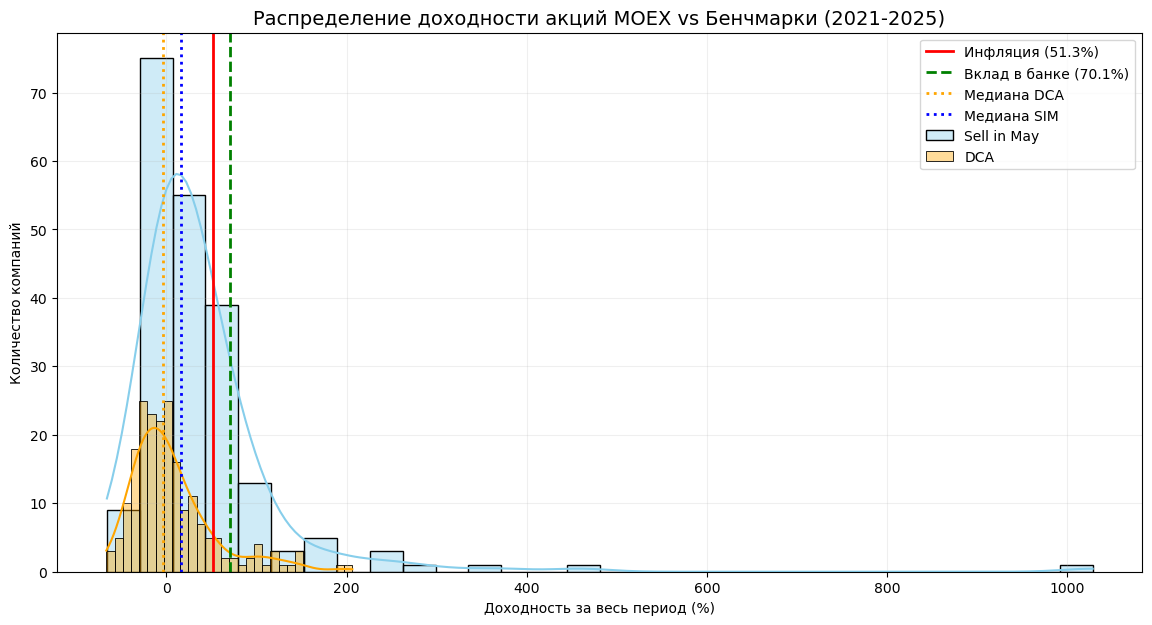

In [ ]:
# # 1. Убеждаемся, что переменные бенчмарков рассчитаны
# df_period = df_market[df_market.index >= 2021]
# total_inflation_pct = ((df_period['Inflation'] + 1).prod() - 1) * 100
# total_bank_pct = ((df_period['BankRate'] + 1).prod() - 1) * 100

# # 2. Добавляем новые колонки в готовый results_df
# results_df['Beats_Inflation_DCA'] = results_df['DCA_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_DCA'] = results_df['DCA_Ret_%'] > total_bank_pct
# results_df['Beats_Inflation_SIM'] = results_df['Sell_in_May_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_SIM'] = results_df['Sell_in_May_Ret_%'] > total_bank_pct

# # 3. Можно также добавить колонку с "Чистой доходностью" (доходность минус инфляция)
# results_df['Real_Ret_DCA%'] = results_df['DCA_Ret_%'] - total_inflation_pct
# results_df['Real_Ret_SIM%'] = results_df['Sell_in_May_Ret_%'] - total_inflation_pct

# # Проверяем результат
# print(f"Бенчмарк инфляции: {total_inflation_pct:.2f}%")
# print(f"Бенчмарк вклада: {total_bank_pct:.2f}%")
# display(results_df.head())

# print("\n" + "="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): {results_df['Beats_Inflation_DCA'].sum()} из {len(results_df)}")
# print("="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): {results_df['Beats_Inflation_SIM'].sum()} из {len(results_df)}")
# print("="*50)

# # Построение графиков
# plt.figure(figsize=(14, 7))
# sns.histplot(results_df["Sell_in_May_Ret_%"], color="skyblue", label="Sell in May", kde=True, bins=30, alpha=0.4)
# sns.histplot(results_df["DCA_Ret_%"], color="orange", label="DCA", kde=True, bins=30, alpha=0.4)

# # Линии бенчмарков
# plt.axvline(total_inflation_pct, color='red', linestyle='-', linewidth=2, label=f'Инфляция ({total_inflation_pct:.1f}%)')
# plt.axvline(total_bank_pct, color='green', linestyle='--', linewidth=2, label=f'Вклад в банке ({total_bank_pct:.1f}%)')
# plt.axvline(results_df["DCA_Ret_%"].median(), color='orange', linestyle=':', linewidth=2, label='Медиана DCA')
# plt.axvline(results_df["Sell_in_May_Ret_%"].median(), color='blue', linestyle=':', linewidth=2, label='Медиана SIM')

# plt.title("Распределение доходности акций MOEX vs Бенчмарки (2021-2025)", fontsize=14)
# plt.xlabel("Доходность за весь период (%)")
# plt.ylabel("Количество компаний")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.show()

In [28]:
# Добавьте это в начало функции run_backtest_with_fine_tuning
total_months = (df_SBER['DateTime'].max() - df_SBER['DateTime'].min()).days // 30
if total_months < TRAIN_MONTHS + TEST_MONTHS:
    print(f"ВНИМАНИЕ: Недостаточно данных! Всего месяцев: {total_months}, нужно минимум: {TRAIN_MONTHS + TEST_MONTHS}")
else:
    print(f"Данных достаточно. Обучение: {TRAIN_MONTHS} мес. Проверка составит примерно {total_months - TRAIN_MONTHS} мес.")

Данных достаточно. Обучение: 24 мес. Проверка составит примерно 71 мес.


In [34]:
from tensorflow.keras import layers, models, optimizers

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax') 
    ])
    
    # Использование legacy оптимизатора для ускорения на M1/M2/M3
    try:
        opt = optimizers.legacy.Adam(learning_rate=0.0001)
        print("Используется оптимизатор legacy.Adam для Mac")
    except AttributeError:
        opt = optimizers.Adam(learning_rate=0.0001)
        print("Используется стандартный Adam")

    model.compile(
        optimizer=opt, 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

In [36]:
def create_tensors(df, window_size=24, alpha=0.55):
    """
    Создает X (тензоры для CNN) и y (таргеты по волатильности).
    """
    df = df.copy().sort_values("DateTime")
    
    # Расчет таргета как в статье
    returns = df['Close'].pct_change()
    volatility = returns.rolling(window=10).std()
    # Изменение цены через 24 свечи (2 часа для 5-мин интервала)
    future_change = (df['Close'].shift(-window_size) - df['Close']) / df['Close']
    
    conditions = [
        (future_change >= alpha * volatility), # Up (1)
        (future_change <= -alpha * volatility) # Down (2)
    ]
    df['Target'] = np.select(conditions, [1, 2], default=0) # Flat (0)
    
    # Фичи: OHLCV (как базовый набор из статьи)
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    data_x = df[features].values
    data_y = df['Target'].values
    dates = df['DateTime'].values
    prices = df['Close'].values

    X, y, out_dates, out_prices = [], [], [], []

    for i in range(window_size, len(df) - window_size):
        # Извлекаем окно
        window = data_x[i-window_size:i]
        
        # Локальная нормализация окна (Z-score) для стабильности CNN
        scaler = StandardScaler()
        norm_window = scaler.fit_transform(window)
        
        X.append(norm_window)
        y.append(data_y[i])
        out_dates.append(dates[i])
        out_prices.append(prices[i])

    return np.array(X), np.array(y), np.array(out_dates), np.array(out_prices)

In [42]:
def run_backtest_with_fine_tuning(df):
    # Используем более жесткие параметры при создании тензоров
    X_all, y_all, dates_all, prices_all = create_tensors(df, alpha=1.5) 
    dt_index = pd.to_datetime(dates_all)
    
    start_date = dt_index.min()
    current_test_start = start_date + DateOffset(months=TRAIN_MONTHS)
    
    model = build_model(input_shape=(WINDOW_SIZE, 5))
    
    print("Первичное обучение...")
    initial_mask = (dt_index >= start_date) & (dt_index < current_test_start)
    # Используем class_weight, так как хороших сигналов теперь мало (они редкие)
    model.fit(X_all[initial_mask], y_all[initial_mask], epochs=15, batch_size=64, verbose=1)
    
    all_preds = []
    CONFIDENCE_THRESHOLD = 0.65 # Фильтр "уверенности"

    while current_test_start < dt_index.max():
        test_end = current_test_start + DateOffset(months=TEST_MONTHS)
        test_mask = (dt_index >= current_test_start) & (dt_index < test_end)
        
        X_test, y_test = X_all[test_mask], y_all[test_mask]
        if len(X_test) == 0: break
            
        probs = model.predict(X_test, verbose=0)
        
        # ЛОГИКА ФИЛЬТРАЦИИ:
        # p[0] - Flat, p[1] - Buy, p[2] - Sell
        final_classes = []
        for p in probs:
            if p[1] > CONFIDENCE_THRESHOLD:
                final_classes.append(1)
            elif p[2] > CONFIDENCE_THRESHOLD:
                final_classes.append(2)
            else:
                final_classes.append(0) # Игнорируем неуверенные сигналы
        
        chunk_results = pd.DataFrame({
            'DateTime': dates_all[test_mask],
            'Price': prices_all[test_mask],
            'Actual': y_test,
            'Predicted': final_classes
        })
        all_preds.append(chunk_results)
        
        print(f"Update: {current_test_start.date()} | Сделок в периоде: {sum(np.array(final_classes) != 0)}")
        
        # Дообучение только на реальных движениях (где y != 0)
        model.fit(X_test, y_test, epochs=1, batch_size=32, verbose=0)
        current_test_start = test_end

    return pd.concat(all_preds)

def run_backtest_with_fine_tuning(df):
    # Используем более жесткие параметры при создании тензоров
    X_all, y_all, dates_all, prices_all = create_tensors(df, alpha=1.5) 
    dt_index = pd.to_datetime(dates_all)
    
    start_date = dt_index.min()
    current_test_start = start_date + DateOffset(months=TRAIN_MONTHS)
    
    model = build_model(input_shape=(WINDOW_SIZE, 5))
    
    print("Первичное обучение...")
    initial_mask = (dt_index >= start_date) & (dt_index < current_test_start)
    # Используем class_weight, так как хороших сигналов теперь мало (они редкие)
    model.fit(X_all[initial_mask], y_all[initial_mask], epochs=15, batch_size=64, verbose=1)
    
    all_preds = []
    CONFIDENCE_THRESHOLD = 0.65 # Фильтр "уверенности"

    while current_test_start < dt_index.max():
        test_end = current_test_start + DateOffset(months=TEST_MONTHS)
        test_mask = (dt_index >= current_test_start) & (dt_index < test_end)
        
        X_test, y_test = X_all[test_mask], y_all[test_mask]
        if len(X_test) == 0: break
            
        probs = model.predict(X_test, verbose=0)
        
        # ЛОГИКА ФИЛЬТРАЦИИ:
        # p[0] - Flat, p[1] - Buy, p[2] - Sell
        final_classes = []
        for p in probs:
            if p[1] > CONFIDENCE_THRESHOLD:
                final_classes.append(1)
            elif p[2] > CONFIDENCE_THRESHOLD:
                final_classes.append(2)
            else:
                final_classes.append(0) # Игнорируем неуверенные сигналы
        
        chunk_results = pd.DataFrame({
            'DateTime': dates_all[test_mask],
            'Price': prices_all[test_mask],
            'Actual': y_test,
            'Predicted': final_classes
        })
        all_preds.append(chunk_results)
        
        print(f"Update: {current_test_start.date()} | Сделок в периоде: {sum(np.array(final_classes) != 0)}")
        
        # Дообучение только на реальных движениях (где y != 0)
        model.fit(X_test, y_test, epochs=1, batch_size=32, verbose=0)
        current_test_start = test_end

    return pd.concat(all_preds)

In [43]:
X_all, y_all, dates_all, prices_all = create_tensors(df_SBER, window_size=24, alpha=1.5)

final_results = run_backtest_with_fine_tuning(df_SBER)

Используется оптимизатор legacy.Adam для Mac
Первичное обучение...
Epoch 1/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4621 - accuracy: 0.7941
Epoch 2/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4259 - accuracy: 0.8026
Epoch 3/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4207 - accuracy: 0.8080
Epoch 4/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4167 - accuracy: 0.8129
Epoch 5/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4127 - accuracy: 0.8181
Epoch 6/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4084 - accuracy: 0.8227
Epoch 7/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.4039 - accuracy: 0.8287
Epoch 8/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.3985 - accuracy: 0.8341
Epoch 9/15
3290/3290 [==============================] - 9s 3ms/step - loss: 0.3925 - accuracy: 0.8393
Epoch 10/15
329

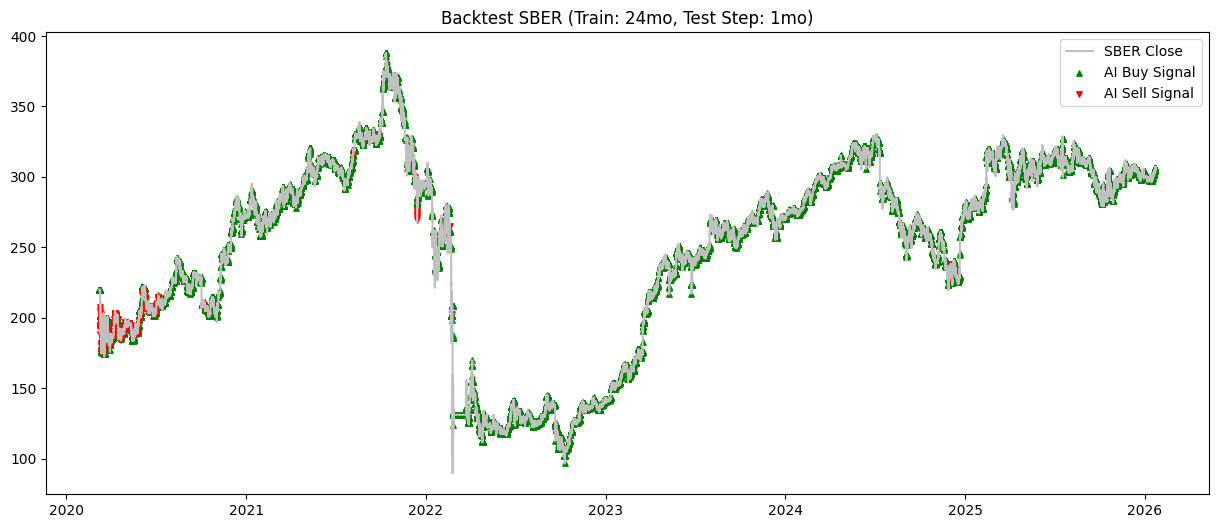

In [44]:
if not final_results.empty:
    # Визуализация (как в предыдущем ответе)
    plt.figure(figsize=(15, 6))
    plt.plot(final_results['DateTime'], final_results['Price'], color='silver', label='SBER Close')
    
    # Сигналы
    up = final_results[final_results['Predicted'] == 1]
    down = final_results[final_results['Predicted'] == 2]
    
    plt.scatter(up['DateTime'], up['Price'], marker='^', color='green', s=15, label='AI Buy Signal')
    plt.scatter(down['DateTime'], down['Price'], marker='v', color='red', s=15, label='AI Sell Signal')
    
    plt.title(f"Backtest SBER (Train: {TRAIN_MONTHS}mo, Test Step: {TEST_MONTHS}mo)")
    plt.legend()
    plt.show()

In [45]:
def analyze_trades(df, commission=0.0003): # 0.03% комиссия Тинькофф
    trades = []
    in_position = False
    entry_price = 0
    entry_date = None
    
    # Итерируемся по результатам бэктеста
    for i in range(len(df)):
        signal = df['Predicted'].iloc[i]
        price = df['Price'].iloc[i]
        date = df['DateTime'].iloc[i]
        
        # Логика входа: Сигнал BUY (1) и мы не в позиции
        if signal == 1 and not in_position:
            in_position = True
            entry_price = price
            entry_date = date
            
        # Логика выхода: Сигнал SELL (2) или окончание данных
        elif (signal == 2 or i == len(df) - 1) and in_position:
            exit_price = price
            exit_date = date
            pnl = (exit_price - entry_price) / entry_price
            # Вычитаем комиссию за вход и выход
            pnl_net = pnl - (commission * 2)
            
            trades.append({
                'Entry Date': entry_date,
                'Exit Date': exit_date,
                'Entry Price': entry_price,
                'Exit Price': exit_price,
                'Profit %': round(pnl_net * 100, 2),
                'Duration': exit_date - entry_date
            })
            in_position = False
            
    trades_df = pd.DataFrame(trades)
    
    # Считаем общие метрики
    if not trades_df.empty:
        win_rate = len(trades_df[trades_df['Profit %'] > 0]) / len(trades_df) * 100
        total_return = trades_df['Profit %'].sum()
        avg_trade = trades_df['Profit %'].mean()
        
        print("-" * 30)
        print(f"ИТОГО ПО СТРАТЕГИИ:")
        print(f"Всего сделок: {len(trades_df)}")
        print(f"Win Rate: {win_rate:.2f}%")
        print(f"Общая доходность: {total_return:.2f}%")
        print(f"Средняя сделка: {avg_trade:.2f}%")
        print("-" * 30)
        
        return trades_df
    else:
        print("Сделок не найдено. Возможно, порог уверенности слишком высок.")
        return None

# Запуск анализа
report_df = analyze_trades(final_results)
if report_df is not None:
    display(report_df.head(20)) # Вывод первых 20 сделок в виде таблицы

------------------------------
ИТОГО ПО СТРАТЕГИИ:
Всего сделок: 112
Win Rate: 48.21%
Общая доходность: 48.92%
Средняя сделка: 0.44%
------------------------------


,Entry Date,Exit Date,Entry Price,Exit Price,Profit %,Duration
0,2020-03-07 20:30:00,2020-03-10 08:00:00,219.99,195.00,-11.42,2 days 11:30:00
1,2020-03-10 09:20:00,2020-03-10 09:35:00,194.82,194.84,-0.05,0 days 00:15:00
2,2020-03-10 09:40:00,2020-03-10 12:25:00,195.54,205.81,5.19,0 days 02:45:00
3,2020-03-10 16:35:00,2020-03-11 07:25:00,201.20,200.81,-0.25,0 days 14:50:00
4,2020-03-11 09:00:00,2020-03-11 10:05:00,200.23,198.47,-0.94,0 days 01:05:00
5,2020-03-11 10:55:00,2020-03-12 08:45:00,200.23,181.83,-9.25,0 days 21:50:00
6,2020-03-12 12:20:00,2020-03-12 15:30:00,180.59,176.76,-2.18,0 days 03:10:00
7,2020-03-12 16:35:00,2020-03-16 08:40:00,175.91,194.64,10.59,3 days 16:05:00
8,2020-03-16 09:15:00,2020-03-16 10:35:00,193.31,192.70,-0.38,0 days 01:20:00
9,2020-03-16 11:25:00,2020-03-17 09:25:00,189.23,189.12,-0.12,0 days 22:00:00
